<a href="https://colab.research.google.com/github/Ashcodes69/Models/blob/main/Plant_disease_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'Ad your Kaggle api token'

In [ ]:
!kaggle datasets download -d "tushar5harma/plant-village-dataset-updated" --unzip

Dataset URL: https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated
License(s): CC0-1.0
100% 1.00G/1.00G [00:09<00:00, 112MB/s]



In [ ]:
# See the folder structure
for root, dirs, files in os.walk('/content'):
    level = root.replace('/content', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # Only show 2 levels deep
        for file in files[:3]:  # Show first 3 files per folder
            print(f'{indent}  {file}')

content/
  .config/
    hidden_gcloud_config_universe_descriptor_data_cache_configs.db
    .last_opt_in_prompt.yaml
    active_config
    configurations/
    logs/
      2026.05.12/
  Grape/
    Test/
      Leaf Blight/
      Healthy/
      Esca (Black Measles)/
      Black Rot/
    Val/
      Leaf Blight/
      Healthy/
      Esca (Black Measles)/
      Black Rot/
    Train/
      Leaf Blight/
      Healthy/
      Esca (Black Measles)/
      Black Rot/
  Cherry/
    Test/
      Healthy/
      Powdery Mildew/
    Val/
      Healthy/
      Powdery Mildew/
    Train/
      Healthy/
      Powdery Mildew/
  drive/
    MyDrive/
      Colab Notebooks/
      archive/
    .shortcut-targets-by-id/
    .Trash-0/
      files/
      info/
    .Encrypted/
      MyDrive/
        Colab Notebooks/
        archive/
      .shortcut-targets-by-id/
  Corn (Maize)/
    Test/
      Common Rust /
      Northern Leaf Blight/
      Healthy/
      Cercospora Leaf Spot/
        .ipynb_checkpoints/
    Val/
     

In [ ]:
import shutil

exclude = {'.config', 'sample_data', 'merged'}

crops = [
    d for d in os.listdir('/content')
    if os.path.isdir(f"/content/{d}")
    and d not in exclude
    ]

print("Crops found: ", crops)

Crops found:  ['Grape', 'Cherry', 'drive', 'Corn (Maize)', 'Apple', 'Potato', 'Strawberry', 'Tomato', 'Bell Pepper', 'Peach']


In [ ]:
from genericpath import exists
splits = ["Train", "Val", "Test"]
total_copied = 0

for split in splits:
    for crop in crops:
        src = f"/content/{crop}/{split}"

        if not os.path.exists(src):
            continue

        for disease_class in os.listdir(src):
            src_class = f"{src}/{disease_class}"

            if not os.path.isdir(src_class):
                continue

            dst_class = f"/content/merged/{split}/{crop}_{disease_class}"

            os.makedirs(dst_class, exist_ok=True)

            for img in os.listdir(src_class):
                img_src = f"{src_class}/{img}"
                img_dst = f'{dst_class}/{img}'
                if os.path.isfile(img_src) and not os.path.exists(img_dst):
                    shutil.copy(img_src, dst_class)
                    total_copied += 1

print("total image copied: ", total_copied)


total image copied:  67111


In [ ]:
for split in splits:
    classes = os.listdir(f'/content/merged/{split}')
    print(f"\n{split} classes ({len(classes)}):", classes)


Train classes (29): ['Potato_Healthy', 'Tomato_Yellow Leaf Curl Virus', 'Potato_Early Blight', 'Tomato_Early Blight', 'Peach_Bacterial Spot', 'Strawberry_Leaf Scorch', 'Apple_Black Rot', 'Corn (Maize)_Cercospora Leaf Spot', 'Cherry_Healthy', 'Apple_Cedar Apple Rust', 'Strawberry_Healthy', 'Tomato_Late Blight', 'Apple_Apple Scab', 'Tomato_Healthy', 'Grape_Leaf Blight', 'Corn (Maize)_Northern Leaf Blight', 'Peach_Healthy', 'Grape_Healthy', 'Apple_Healthy', 'Cherry_Powdery Mildew', 'Tomato_Septoria Leaf Spot', 'Grape_Black Rot', 'Potato_Late Blight', 'Corn (Maize)_Common Rust ', 'Grape_Esca (Black Measles)', 'Bell Pepper_Bacterial Spot', 'Corn (Maize)_Healthy', 'Tomato_Bacterial Spot', 'Bell Pepper_Healthy']

Val classes (29): ['Potato_Healthy', 'Tomato_Yellow Leaf Curl Virus', 'Potato_Early Blight', 'Tomato_Early Blight', 'Peach_Bacterial Spot', 'Strawberry_Leaf Scorch', 'Apple_Black Rot', 'Corn (Maize)_Cercospora Leaf Spot', 'Cherry_Healthy', 'Apple_Cedar Apple Rust', 'Strawberry_Healt

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

temp_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
    ])

temp_dataset = datasets.ImageFolder(
    root="/content/merged/Train",
    transform=temp_transform
    )
temp_loader = DataLoader(
    dataset=temp_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

mean = torch.zeros(3)
std = torch.zeros(3)
total_images = 0

for images, _ in temp_loader:
    for i in range(3):
        mean[i] += images[:, i, :, :].mean()
        std[i] +=images[:, i, :, :].std()
        total_images += images.size(0)

mean /= len(temp_loader)
std /= len(temp_loader)

print(f"Mean: {mean}")
print(f"Std: {std}")
print(f"Num of Images: {total_images}")

Mean: tensor([0.4701, 0.4961, 0.4185])
Std: tensor([0.1979, 0.1747, 0.2140])
Num of Images: 161070


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

mean = [0.4701, 0.4961, 0.4185]
std  = [0.1979, 0.1747, 0.2140]
train_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dataset = datasets.ImageFolder(
    "/content/merged/Train",
    transform=train_transform
    )
val_dataset = datasets.ImageFolder(
    "/content/merged/Val",
    transform=val_test_transform
    )
test_dataset = datasets.ImageFolder(
    "/content/merged/Test",
    transform=val_test_transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Train samples:", len(train_dataset))
print("Val samples:  ", len(val_dataset))
print("Test samples: ", len(test_dataset))
print("Classes:      ", len(train_dataset.classes))

Train samples: 53690
Val samples:   12067
Test samples:  1354
Classes:       29


In [ ]:
import torch.nn as nn

class PlantDiseaseCNN_V0(nn.Module):
    def __init__(self, num_classes=29):
        super(PlantDiseaseCNN_V0, self).__init__()

        self.features = nn.Sequential(
            # layer 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # layer 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # layer 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # layer 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"
model_1 = PlantDiseaseCNN_V0(num_classes=len(train_dataset.classes)).to(device)
model_1, device

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

In [ ]:
import time
def train(model, train_loader, val_loader, epochs):

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc' : [], 'val_acc' : []
    }

    print("=" * 60)
    print("Training Started!")
    print("=" * 60)
    total_start = time.time()

    for epoch in range(epochs):

        model.train()
        train_loss, train_correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1)==labels).sum().item()

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.inference_mode():

            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()


        train_acc = 100 * train_correct / len(train_loader.dataset)
        val_acc = 100 * val_correct / len(val_loader.dataset)
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)

        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train loss: {train_loss_avg:.4f} | Train acc: {train_acc:.2f}% | "
            f"Val loss: {val_loss_avg:.4f} | Val acc: {val_acc:.2f}%"
            )

    total_time = time.time() - total_start
    print("=" * 60)
    print(f"Training Complete! Total time: {total_time/60:.2f} mins")
    print("=" * 60)

    return history


In [ ]:
history = train(
    model=model_1,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20
)

Training Started!
Epoch [1/20] | Train loss: 1.0148 | Train acc: 67.90% | Val loss: 0.4393 | Val acc: 85.90%
Epoch [2/20] | Train loss: 0.4351 | Train acc: 85.50% | Val loss: 0.1961 | Val acc: 93.57%
Epoch [3/20] | Train loss: 0.3018 | Train acc: 89.97% | Val loss: 0.3420 | Val acc: 89.59%
Epoch [4/20] | Train loss: 0.2345 | Train acc: 92.33% | Val loss: 0.1179 | Val acc: 95.96%
Epoch [5/20] | Train loss: 0.1940 | Train acc: 93.58% | Val loss: 0.0931 | Val acc: 97.04%
Epoch [6/20] | Train loss: 0.1614 | Train acc: 94.65% | Val loss: 0.0826 | Val acc: 97.19%
Epoch [7/20] | Train loss: 0.1421 | Train acc: 95.32% | Val loss: 0.0675 | Val acc: 97.84%
Epoch [8/20] | Train loss: 0.1277 | Train acc: 95.84% | Val loss: 0.1596 | Val acc: 95.14%
Epoch [9/20] | Train loss: 0.1143 | Train acc: 96.23% | Val loss: 0.0492 | Val acc: 98.52%
Epoch [10/20] | Train loss: 0.1061 | Train acc: 96.53% | Val loss: 0.0667 | Val acc: 97.89%
Epoch [11/20] | Train loss: 0.0956 | Train acc: 96.89% | Val loss: 0.05

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(model_1.state_dict(), '/content/drive/MyDrive/plant_disease_model.pth')
print("Model saved")


Mounted at /content/drive
Model saved


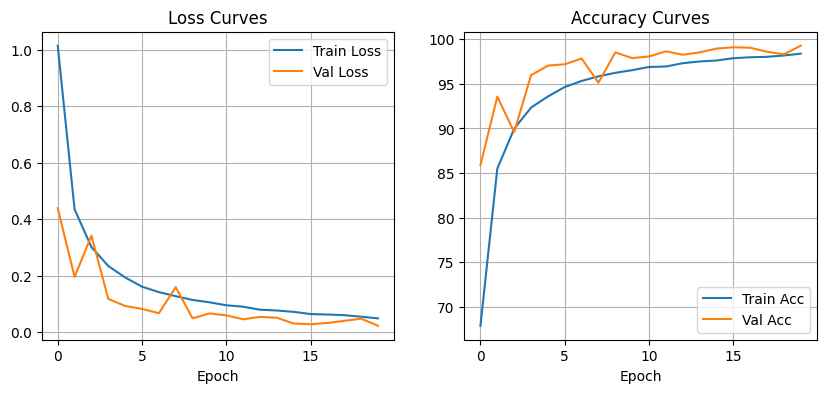

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.grid()
ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'],   label='Val Acc')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.grid()
ax2.legend()

plt.show()

In [ ]:
model_1.eval()
test_correct, test_loss = 0, 0
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_1(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()
        test_correct += (outputs.argmax(1) == labels).sum().item()

test_acc = 100 * test_correct /len(test_loader.dataset)
test_loss_avg = test_loss / len(test_loader)
print(f"Test-acc: {test_acc:.2f} | Test-loss: {test_loss_avg:.4f}")

Test-acc: 99.34 | Test-loss: 0.0228


In [ ]:
# !pip install onnxscript onnx
# !pip install onnxruntime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 84.0 MB/s eta 0:00:00


In [ ]:
import torch
from google.colab import drive
drive.mount('/content/drive')

model = PlantDiseaseCNN_V0(num_classes = 29).to("cpu")
model.load_state_dict(torch.load('/content/drive/MyDrive/plant_disease_model.pth', map_location="cpu"))
model.eval()

dummy_input= torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input,
    '/content/drive/MyDrive/plant_disease_model.onnx',
    export_params= True,
    opset_version= 11,
    input_names= ['input'],
    output_names= ['output'],
    dynamic_axes= {
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)
print("ONNX model exported!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_9092/3969556653.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0516 01:23:58.500000 9092 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `PlantDiseaseCNN_V0([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `PlantDiseaseCNN_V0([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model exported!


In [ ]:
import onnxruntime as ort
import numpy as np

ort_session = ort.InferenceSession('/content/drive/MyDrive/plant_disease_model.onnx')
test_input  = np.random.randn(1, 3, 224, 224).astype(np.float32)
outputs     = ort_session.run(None, {'input': test_input})
print(f"Output shape: {outputs[0].shape}")  # Should be (1, 29)
print("ONNX model verified!")


Output shape: (1, 29)
ONNX model verified!


In [ ]:
import json
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

class_orderd = [idx_to_class[i] for i in range(len(idx_to_class))]
print(json.dumps(class_orderd, indent=2))

[
  "Apple_Apple Scab",
  "Apple_Black Rot",
  "Apple_Cedar Apple Rust",
  "Apple_Healthy",
  "Bell Pepper_Bacterial Spot",
  "Bell Pepper_Healthy",
  "Cherry_Healthy",
  "Cherry_Powdery Mildew",
  "Corn (Maize)_Cercospora Leaf Spot",
  "Corn (Maize)_Common Rust ",
  "Corn (Maize)_Healthy",
  "Corn (Maize)_Northern Leaf Blight",
  "Grape_Black Rot",
  "Grape_Esca (Black Measles)",
  "Grape_Healthy",
  "Grape_Leaf Blight",
  "Peach_Bacterial Spot",
  "Peach_Healthy",
  "Potato_Early Blight",
  "Potato_Healthy",
  "Potato_Late Blight",
  "Strawberry_Healthy",
  "Strawberry_Leaf Scorch",
  "Tomato_Bacterial Spot",
  "Tomato_Early Blight",
  "Tomato_Healthy",
  "Tomato_Late Blight",
  "Tomato_Septoria Leaf Spot",
  "Tomato_Yellow Leaf Curl Virus"
]
